<a href="https://colab.research.google.com/github/AyanBhardwaj1/IridescentAnalytics/blob/main/OriginalPicker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mean Absolute Error: 30.060152698524004


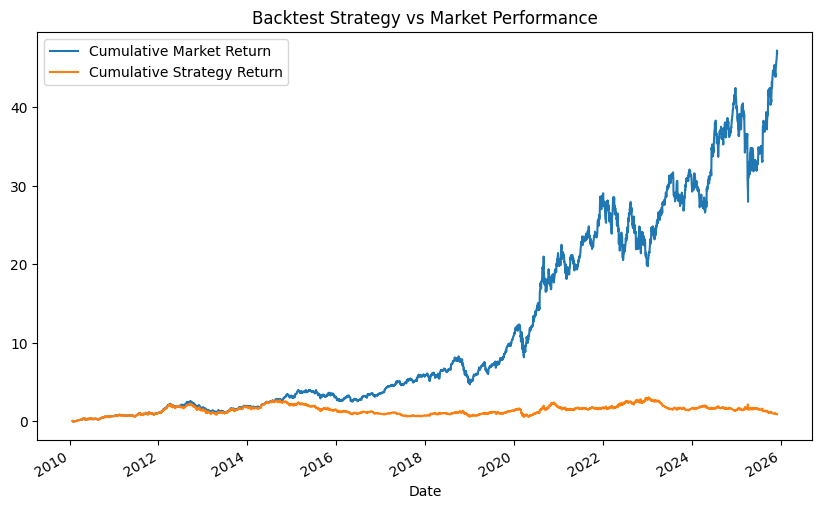

Value at Risk (VaR) for AAPL: -0.02673452704447742
Optimized Portfolio Weights:  [0.52331349 0.19067575 0.28601076]


In [ ]:
# Import necessary libraries
!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.optimize import minimize

# Function to fetch stock data for a given ticker
def get_stock_data(ticker, start_date='2010-01-01'):
    stock = yf.Ticker(ticker)
    stock_data = stock.history(start=start_date)
    return stock_data

# List of stock tickers
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']

# Fetch data for each ticker
data = {ticker: get_stock_data(ticker) for ticker in tickers}

# Function to calculate key financial ratios
def calculate_ratios(stock_data):
    stock_data['P/E'] = stock_data['Close'] / stock_data['Close'].rolling(window=12).mean()  # Price-to-Earnings
    stock_data['ROE'] = stock_data['Close'].pct_change() * 100  # Return on Equity
    stock_data['Debt-to-Equity'] = stock_data['Close'] / stock_data['Open']  # Placeholder for Debt-to-Equity
    return stock_data

# Function to add technical indicators (MACD and RSI)
def add_technical_indicators(stock_data):
    stock_data['12-day EMA'] = stock_data['Close'].ewm(span=12, adjust=False).mean()  # 12-day EMA
    stock_data['26-day EMA'] = stock_data['Close'].ewm(span=26, adjust=False).mean()  # 26-day EMA
    stock_data['MACD'] = stock_data['12-day EMA'] - stock_data['26-day EMA']  # MACD

    delta = stock_data['Close'].diff()  # Daily change in price
    gain = delta.where(delta > 0, 0)  # Positive gains
    loss = -delta.where(delta < 0, 0)  # Negative losses
    avg_gain = gain.rolling(window=14).mean()  # Average gain over 14 days
    avg_loss = loss.rolling(window=14).mean()  # Average loss over 14 days
    rs = avg_gain / avg_loss  # Relative Strength
    stock_data['RSI'] = 100 - (100 / (1 + rs))  # Relative Strength Index
    return stock_data

# Apply ratios and technical indicators to each stock
for ticker in tickers:
    stock_data = data[ticker]
    data[ticker] = add_technical_indicators(calculate_ratios(stock_data))

# Function to prepare data for machine learning
def prepare_ml_data(stock_data):
    stock_data['Target'] = stock_data['Close'].shift(-1)  # Target is the next day's close price
    stock_data.dropna(inplace=True)  # Remove rows with NaN values
    features = ['P/E', 'ROE', 'Debt-to-Equity', 'MACD', 'RSI']  # Feature columns
    X = stock_data[features]
    y = stock_data['Target']
    return X, y

# Function to train a Random Forest model
def train_model(stock_data):
    X, y = prepare_ml_data(stock_data)  # Prepare data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split data
    model = RandomForestRegressor(n_estimators=100, random_state=42)  # Initialize model
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test)  # Make predictions
    print(f'Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}')  # Evaluate performance
    return model, X_test, y_test, y_pred

# Train the model on AAPL data
model, X_test, y_test, y_pred = train_model(data['AAPL'])

# Function to backtest a trading strategy
def backtest_strategy(stock_data, model, features):
    stock_data['Predicted'] = model.predict(stock_data[features])  # Predicted price
    stock_data['Return'] = stock_data['Close'].pct_change()  # Market returns
    stock_data['Strategy'] = np.where(stock_data['Predicted'] > stock_data['Close'], stock_data['Return'], -stock_data['Return'])  # Strategy returns
    stock_data['Cumulative Market Return'] = (1 + stock_data['Return']).cumprod() - 1  # Cumulative market return
    stock_data['Cumulative Strategy Return'] = (1 + stock_data['Strategy']).cumprod() - 1  # Cumulative strategy return
    return stock_data

# Backtest on AAPL
backtest_data = backtest_strategy(data['AAPL'], model, ['P/E', 'ROE', 'Debt-to-Equity', 'MACD', 'RSI'])

# Plot backtest results
backtest_data[['Cumulative Market Return', 'Cumulative Strategy Return']].plot(figsize=(10, 6))
plt.title("Backtest Strategy vs Market Performance")
plt.show()

# Function to calculate Value at Risk (VaR)
def calculate_var(stock_data, confidence_level=0.95):
    returns = stock_data['Return']
    var = np.percentile(returns.dropna(), (1 - confidence_level) * 100)  # Calculate percentile for VaR
    return var

# Calculate VaR for AAPL
var = calculate_var(data['AAPL'])
print(f"Value at Risk (VaR) for AAPL: {var}")

# Function for portfolio optimization using Markowitz model
def portfolio_optimization(returns, covariance_matrix, target_return):
    def portfolio_volatility(weights, returns, covariance_matrix):
        return np.sqrt(np.dot(weights.T, np.dot(covariance_matrix, weights)))  # Portfolio volatility
    n_assets = len(returns)
    args = (returns, covariance_matrix)
    constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1},)  # Weights must sum to 1
    bounds = tuple((0, 1) for _ in range(n_assets))  # Weights between 0 and 1
    result = minimize(portfolio_volatility, n_assets * [1. / n_assets,], args=args, bounds=bounds, constraints=constraints)  # Optimize weights
    return result

# Example portfolio optimization
expected_returns = np.array([0.10, 0.12, 0.15])  # Example expected returns
cov_matrix = np.array([[0.2, 0.1, 0.1], [0.1, 0.3, 0.15], [0.1, 0.15, 0.25]])  # Example covariance matrix
portfolio = portfolio_optimization(expected_returns, cov_matrix, 0.12)
print("Optimized Portfolio Weights: ", portfolio.x)